In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/gridlock-round2-cleaned-dataset/events_incident_level.parquet


# Phase 2

## Spatial Zoning

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

from pyproj import Transformer

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

input_files = list(
    Path("/kaggle/input").rglob("events_incident_level.parquet")
)

if not input_files:
    raise FileNotFoundError(
        "events_incident_level.parquet was not found."
    )

DATA_PATH = input_files[0]
OUTPUT_DIR = Path("/kaggle/working/parking_phase2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

events_incident = pd.read_parquet(DATA_PATH)

assert len(events_incident) == 292730
assert events_incident["final_incident_id"].is_unique
assert events_incident[["latitude", "longitude"]].notna().all().all()

print("Loaded:", DATA_PATH)
print("Shape:", events_incident.shape)

Loaded: /kaggle/input/datasets/sahilhussain2410/gridlock-round2-cleaned-dataset/events_incident_level.parquet
Shape: (292730, 70)


In [3]:
# project coordinates into meters
to_utm = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32643",
    always_xy=True
)

to_wgs84 = Transformer.from_crs(
    "EPSG:32643",
    "EPSG:4326",
    always_xy=True
)

x_m, y_m = to_utm.transform(
    events_incident["longitude"].to_numpy(),
    events_incident["latitude"].to_numpy()
)

events_incident["x_m"] = x_m
events_incident["y_m"] = y_m

projection_summary = pd.DataFrame({
    "coordinate": ["x_m", "y_m"],
    "minimum": [
        events_incident["x_m"].min(),
        events_incident["y_m"].min()
    ],
    "maximum": [
        events_incident["x_m"].max(),
        events_incident["y_m"].max()
    ],
    "range_metres": [
        events_incident["x_m"].max()
        - events_incident["x_m"].min(),
        events_incident["y_m"].max()
        - events_incident["y_m"].min()
    ]
})

display(projection_summary)

,coordinate,minimum,maximum,range_metres
0,x_m,"764,870.2289","800,697.0047","35,826.7758"
1,y_m,"1,416,849.7058","1,471,008.5633","54,158.8574"


In [4]:
# Each incident is assigned a reproducible grid ID using its UTM coordinates.
# Zone lookup tables contain the zone centroid, incident count and corresponding latitude/longitude.
GRID_SIZES = [150, 250, 400]

zone_lookups = {}
resolution_rows = []

for size in GRID_SIZES:
    gx_col = f"grid_x_{size}"
    gy_col = f"grid_y_{size}"
    zone_col = f"zone_{size}m"

    events_incident[gx_col] = np.floor(
        events_incident["x_m"] / size
    ).astype("int32")

    events_incident[gy_col] = np.floor(
        events_incident["y_m"] / size
    ).astype("int32")

    events_incident[zone_col] = (
        size.__str__()
        + "_"
        + events_incident[gx_col].astype(str)
        + "_"
        + events_incident[gy_col].astype(str)
    )

    zone_lookup = (
        events_incident
        .groupby([zone_col, gx_col, gy_col], as_index=False)
        .agg(
            incident_count=("final_incident_id", "size"),
            unique_vehicles=("vehicle_token", "nunique")
        )
    )

    zone_lookup["centroid_x_m"] = (
        zone_lookup[gx_col] + 0.5
    ) * size

    zone_lookup["centroid_y_m"] = (
        zone_lookup[gy_col] + 0.5
    ) * size

    centroid_lon, centroid_lat = to_wgs84.transform(
        zone_lookup["centroid_x_m"].to_numpy(),
        zone_lookup["centroid_y_m"].to_numpy()
    )

    zone_lookup["centroid_latitude"] = centroid_lat
    zone_lookup["centroid_longitude"] = centroid_lon

    counts = zone_lookup["incident_count"].sort_values(
        ascending=False
    )

    top_zone_count = max(1, int(np.ceil(len(counts) * 0.10)))

    resolution_rows.append({
        "grid_size_metres": size,
        "active_zones": len(counts),
        "mean_incidents_per_zone": counts.mean(),
        "median_incidents_per_zone": counts.median(),
        "p75_incidents_per_zone": counts.quantile(0.75),
        "p90_incidents_per_zone": counts.quantile(0.90),
        "maximum_incidents_in_zone": counts.max(),
        "singleton_zone_percent": (
            counts.eq(1).mean() * 100
        ),
        "zones_with_5_or_fewer_percent": (
            counts.le(5).mean() * 100
        ),
        "incidents_in_singleton_zones_percent": (
            counts[counts.eq(1)].sum()
            / counts.sum() * 100
        ),
        "incidents_in_top_10_percent_zones": (
            counts.head(top_zone_count).sum()
            / counts.sum() * 100
        )
    })

    zone_lookups[size] = zone_lookup

resolution_comparison = pd.DataFrame(resolution_rows)

display(resolution_comparison)

,grid_size_metres,active_zones,mean_incidents_per_zone,median_incidents_per_zone,p75_incidents_per_zone,p90_incidents_per_zone,maximum_incidents_in_zone,singleton_zone_percent,zones_with_5_or_fewer_percent,incidents_in_singleton_zones_percent,incidents_in_top_10_percent_zones
0,150,5764,50.7859,6.0000,23.0000,93.0000,4375,20.8362,48.6294,0.4103,78.2622
1,250,3452,84.8001,9.0000,37.0000,152.0000,6701,17.7289,41.0776,0.2091,79.3403
2,400,2020,144.9158,15.0000,66.0000,294.3000,11622,12.7723,32.5743,0.0881,78.1010


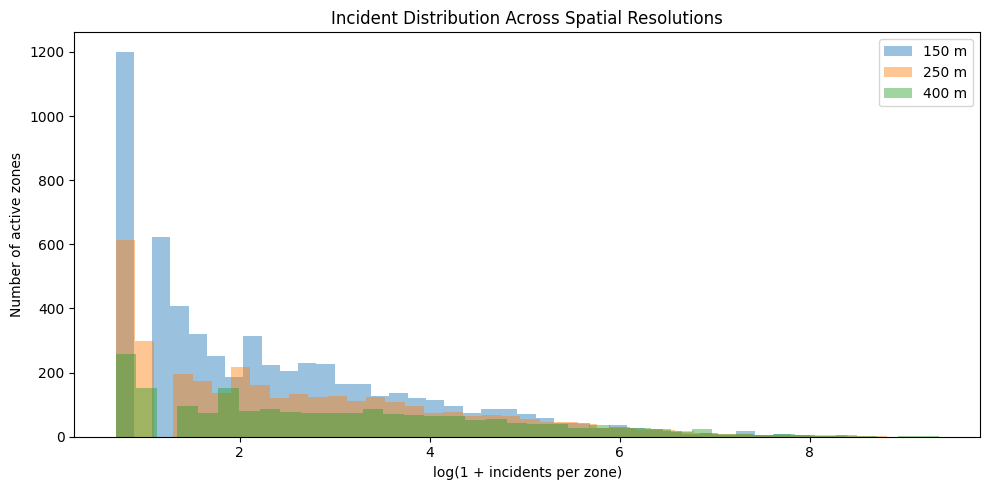

In [5]:
# visualizes how concentrated or sparse each spatial resolution is.
# A very small grid may create many weak zones, while a very large grid may merge distinct hotspots
zone_count_plot = pd.concat(
    [
        zone_lookups[size][["incident_count"]]
        .assign(grid_size=f"{size} m")
        for size in GRID_SIZES
    ],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

for size in GRID_SIZES:
    values = zone_lookups[size]["incident_count"]

    plt.hist(
        np.log1p(values),
        bins=40,
        alpha=0.45,
        label=f"{size} m"
    )

plt.xlabel("log(1 + incidents per zone)")
plt.ylabel("Number of active zones")
plt.title("Incident Distribution Across Spatial Resolutions")
plt.legend()
plt.tight_layout()
plt.show()

## Choose the Temporal Window

In [6]:
# confirms that the primary zone assignment and local event timestamp are available.
# It also sorts incidents chronologically before temporal aggregation.
required_columns = [
    "final_incident_id",
    "zone_250m",
    "created_at_ist"
]

missing_columns = [
    col for col in required_columns
    if col not in events_incident.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

events_incident = events_incident.sort_values(
    "created_at_ist"
).copy()

print("Incidents:", len(events_incident))
print("Active 250 m zones:", events_incident["zone_250m"].nunique())
print("Start:", events_incident["created_at_ist"].min())
print("End:  ", events_incident["created_at_ist"].max())

Incidents: 292730
Active 250 m zones: 3452
Start: 2023-11-10 00:41:46+05:30
End:   2024-04-08 23:00:46+05:30


In [7]:
# For each window size, this measures zone-time sparsity, incidents per active cell 
# and how often a zone remains active in the immediately following window

TEMPORAL_WINDOWS = {
    "30_minutes": "30min",
    "1_hour": "1h",
    "2_hours": "2h"
}

temporal_results = []
temporal_aggregates = {}

for name, frequency in TEMPORAL_WINDOWS.items():

    window_col = f"time_window_{name}"

    events_incident[window_col] = (
        events_incident["created_at_ist"]
        .dt.floor(frequency)
    )

    aggregated = (
        events_incident
        .groupby(
            ["zone_250m", window_col],
            as_index=False
        )
        .agg(
            incident_count=("final_incident_id", "size"),
            unique_vehicles=("vehicle_token", "nunique")
        )
        .rename(columns={window_col: "time_window"})
        .sort_values(["zone_250m", "time_window"])
    )

    temporal_aggregates[name] = aggregated

    window_delta = pd.Timedelta(frequency)

    start = aggregated["time_window"].min()
    end = aggregated["time_window"].max()

    total_windows = (
        int((end - start) / window_delta) + 1
    )

    active_zones = events_incident["zone_250m"].nunique()
    possible_cells = active_zones * total_windows
    active_cells = len(aggregated)

    previous_activity = aggregated[
        ["zone_250m", "time_window"]
    ].copy()

    previous_activity["time_window"] += window_delta
    previous_activity["active_previous_window"] = True

    continuity = aggregated.merge(
        previous_activity,
        on=["zone_250m", "time_window"],
        how="left"
    )

    activity_per_window = (
        aggregated.groupby("time_window")["zone_250m"]
        .nunique()
    )

    temporal_results.append({
        "temporal_resolution": name,
        "total_time_windows": total_windows,
        "possible_zone_time_cells": possible_cells,
        "active_zone_time_cells": active_cells,
        "active_cell_percent": (
            active_cells / possible_cells * 100
        ),
        "mean_incidents_per_active_cell": (
            aggregated["incident_count"].mean()
        ),
        "median_incidents_per_active_cell": (
            aggregated["incident_count"].median()
        ),
        "p90_incidents_per_active_cell": (
            aggregated["incident_count"].quantile(0.90)
        ),
        "singleton_active_cell_percent": (
            aggregated["incident_count"].eq(1).mean() * 100
        ),
        "mean_active_zones_per_window": (
            activity_per_window.mean()
        ),
        "median_active_zones_per_window": (
            activity_per_window.median()
        ),
        "previous_window_active_percent": (
            continuity["active_previous_window"]
            .fillna(False)
            .mean() * 100
        )
    })

temporal_comparison = pd.DataFrame(temporal_results)

display(temporal_comparison)

/tmp/ipykernel_16/2905819111.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_16/2905819111.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_16/2905819111.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,temporal_resolution,total_time_windows,possible_zone_time_cells,active_zone_time_cells,active_cell_percent,mean_incidents_per_active_cell,median_incidents_per_active_cell,p90_incidents_per_active_cell,singleton_active_cell_percent,mean_active_zones_per_window,median_active_zones_per_window,previous_window_active_percent
0,30_minutes,7246,25013192,97917,0.3915,2.9896,2.0000,7.0000,49.3980,18.6083,18.0000,22.5364
1,1_hour,3624,12510048,86945,0.6950,3.3668,2.0000,8.0000,46.7479,30.7988,32.0000,24.1808
2,2_hours,1812,6255024,76359,1.2208,3.8336,2.0000,9.0000,44.1651,50.8382,55.0000,24.5079


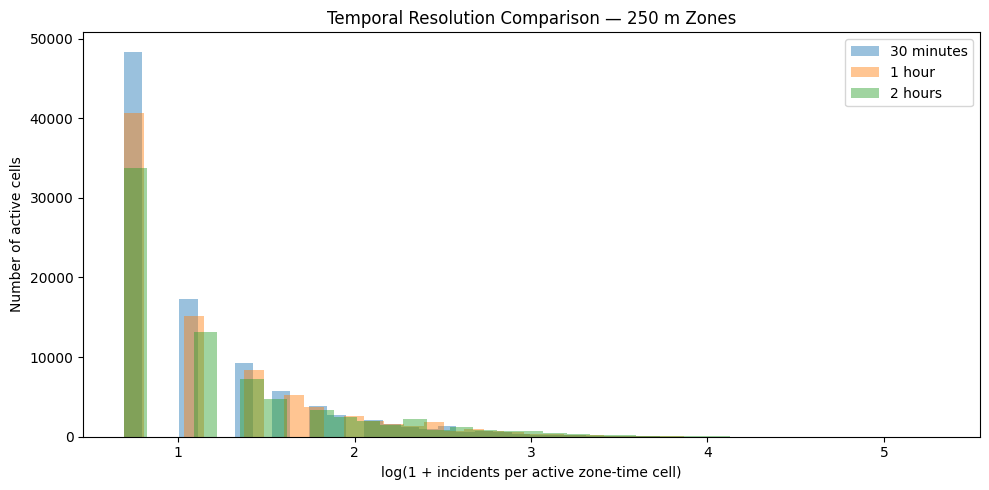

In [8]:
# compares how much signal each active zone-time cell contains
plt.figure(figsize=(10, 5))

for name, aggregated in temporal_aggregates.items():
    plt.hist(
        np.log1p(aggregated["incident_count"]),
        bins=35,
        alpha=0.45,
        label=name.replace("_", " ")
    )

plt.xlabel("log(1 + incidents per active zone-time cell)")
plt.ylabel("Number of active cells")
plt.title("Temporal Resolution Comparison — 250 m Zones")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# saving temporal comaprison outputs

temporal_comparison.to_csv(
    OUTPUT_DIR / "temporal_resolution_comparison.csv",
    index=False
)

for name, aggregated in temporal_aggregates.items():
    aggregated.to_parquet(
        OUTPUT_DIR / f"active_zone_time_{name}.parquet",
        index=False
    )

events_incident.to_parquet(
    OUTPUT_DIR / "events_with_spatial_temporal_candidates.parquet",
    index=False
)

print("Saved temporal comparison outputs.")

Saved temporal comparison outputs.


## Build the Zone-Time Panel

In [10]:
# calculates each zone’s total incidents, active hours and active days. 
# It compares several support rules so that the dense panel retains most incidents without including thousands of nearly empty zones
events_incident["time_window_1h"] = (
    events_incident["created_at_ist"].dt.floor("1h")
)

zone_support = (
    events_incident.groupby("zone_250m")
    .agg(
        total_incidents=("final_incident_id", "size"),
        active_hours=("time_window_1h", "nunique"),
        active_days=("time_window_1h", lambda x: x.dt.date.nunique()),
        first_event=("time_window_1h", "min"),
        last_event=("time_window_1h", "max")
    )
    .reset_index()
)

candidate_rules = [
    (5, 2),
    (10, 3),
    (20, 5),
    (30, 5),
    (50, 10)
]

rule_rows = []

for minimum_incidents, minimum_days in candidate_rules:
    eligible = (
        zone_support["total_incidents"].ge(minimum_incidents)
        & zone_support["active_days"].ge(minimum_days)
    )

    retained_incidents = zone_support.loc[
        eligible, "total_incidents"
    ].sum()

    rule_rows.append({
        "minimum_incidents": minimum_incidents,
        "minimum_active_days": minimum_days,
        "eligible_zones": int(eligible.sum()),
        "zone_percent": eligible.mean() * 100,
        "incident_coverage_percent": (
            retained_incidents
            / zone_support["total_incidents"].sum()
            * 100
        ),
        "estimated_dense_rows": (
            int(eligible.sum()) * 3624
        )
    })

support_rule_comparison = pd.DataFrame(rule_rows)

display(support_rule_comparison)

,minimum_incidents,minimum_active_days,eligible_zones,zone_percent,incident_coverage_percent,estimated_dense_rows
0,5,2,2098,60.7764,98.9390,7603152
1,10,3,1613,46.7265,97.7464,5845512
2,20,5,1163,33.6906,95.3739,4214712
3,30,5,962,27.8679,93.7082,3486288
4,50,10,703,20.3650,90.1254,2547672


In [11]:
# chooses the rule with the fewest zones while retaining at least 95% of all incidents
# low supported zones are marked but not deleted
valid_rules = support_rule_comparison.loc[
    support_rule_comparison["incident_coverage_percent"] >= 95
]

if valid_rules.empty:
    selected_rule = support_rule_comparison.iloc[0]
else:
    selected_rule = (
        valid_rules
        .sort_values(
            ["eligible_zones", "minimum_incidents"],
            ascending=[True, False]
        )
        .iloc[0]
    )

MIN_INCIDENTS = int(selected_rule["minimum_incidents"])
MIN_ACTIVE_DAYS = int(selected_rule["minimum_active_days"])

zone_support["model_eligible"] = (
    zone_support["total_incidents"].ge(MIN_INCIDENTS)
    & zone_support["active_days"].ge(MIN_ACTIVE_DAYS)
)

eligible_zones = (
    zone_support.loc[
        zone_support["model_eligible"],
        "zone_250m"
    ]
    .sort_values()
    .tolist()
)

zone_id_map = pd.DataFrame({
    "zone_250m": eligible_zones,
    "zone_index": np.arange(
        len(eligible_zones),
        dtype=np.int32
    )
})

selection_summary = pd.DataFrame({
    "metric": [
        "selected_minimum_incidents",
        "selected_minimum_active_days",
        "eligible_zones",
        "excluded_low_support_zones",
        "incident_coverage_percent"
    ],
    "value": [
        MIN_INCIDENTS,
        MIN_ACTIVE_DAYS,
        len(eligible_zones),
        len(zone_support) - len(eligible_zones),
        (
            zone_support.loc[
                zone_support["model_eligible"],
                "total_incidents"
            ].sum()
            / zone_support["total_incidents"].sum()
            * 100
        )
    ]
})

display(selection_summary)

,metric,value
0,selected_minimum_incidents,20.0000
1,selected_minimum_active_days,5.0000
2,eligible_zones,"1,163.0000"
3,excluded_low_support_zones,"2,289.0000"
4,incident_coverage_percent,95.3739


In [12]:
# creates basic hourly evidence for each eligible zone, including incident counts, 
# unique vehicles, observation diversity and obstruction-context counts.
# Missing zone-hour combinations are explicitly filled with zero

events_incident["named_junction_flag"] = (
    events_incident["junction_name"]
    .astype("string")
    .str.upper()
    .fillna("UNKNOWN JUNCTION")
    .ne("NO JUNCTION")
    & events_incident["junction_name"]
    .astype("string")
    .str.upper()
    .fillna("UNKNOWN JUNCTION")
    .ne("UNKNOWN JUNCTION")
).astype("int8")

eligible_events = (
    events_incident[
        events_incident["zone_250m"].isin(eligible_zones)
    ]
    .merge(
        zone_id_map,
        on="zone_250m",
        how="left",
        validate="many_to_one"
    )
)

active_zone_time = (
    eligible_events
    .groupby(
        ["zone_index", "time_window_1h"],
        as_index=False
    )
    .agg(
        incident_count=("final_incident_id", "size"),
        unique_vehicles=("vehicle_token", "nunique"),
        unique_devices=("device_id", "nunique"),
        unique_creators=("created_by_id", "nunique"),
        named_junction_events=("named_junction_flag", "sum"),
        main_road_events=("main_road_flag", "sum"),
        road_crossing_events=("road_crossing_flag", "sum"),
        footpath_events=("footpath_flag", "sum"),
        large_vehicle_events=("large_vehicle_flag", "sum"),
        multi_capture_incidents=("was_multi_capture_incident", "sum"),
        raw_capture_count=("duplicate_capture_count", "sum")
    )
)

all_hours = pd.date_range(
    events_incident["time_window_1h"].min(),
    events_incident["time_window_1h"].max(),
    freq="1h"
)

full_index = pd.MultiIndex.from_product(
    [
        zone_id_map["zone_index"],
        all_hours
    ],
    names=["zone_index", "time_window"]
)

zone_time_panel = (
    active_zone_time
    .rename(columns={"time_window_1h": "time_window"})
    .set_index(["zone_index", "time_window"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

count_columns = [
    col for col in zone_time_panel.columns
    if col not in ["zone_index", "time_window"]
]

zone_time_panel["zone_index"] = (
    zone_time_panel["zone_index"].astype("int32")
)

zone_time_panel[count_columns] = (
    zone_time_panel[count_columns].astype("int32")
)

zone_time_panel["is_active"] = (
    zone_time_panel["incident_count"] > 0
).astype("int8")

panel_summary = pd.DataFrame({
    "metric": [
        "eligible_zones",
        "hourly_windows",
        "panel_rows",
        "active_rows",
        "active_row_percent",
        "incidents_in_panel"
    ],
    "value": [
        zone_time_panel["zone_index"].nunique(),
        zone_time_panel["time_window"].nunique(),
        len(zone_time_panel),
        int(zone_time_panel["is_active"].sum()),
        zone_time_panel["is_active"].mean() * 100,
        int(zone_time_panel["incident_count"].sum())
    ]
})

display(panel_summary)
display(zone_time_panel.head())

,metric,value
0,eligible_zones,"1,163.0000"
1,hourly_windows,"3,624.0000"
2,panel_rows,"4,214,712.0000"
3,active_rows,"79,119.0000"
4,active_row_percent,1.8772
5,incidents_in_panel,"279,188.0000"


,zone_index,time_window,incident_count,unique_vehicles,unique_devices,unique_creators,named_junction_events,main_road_events,road_crossing_events,footpath_events,large_vehicle_events,multi_capture_incidents,raw_capture_count,is_active
0,0,2023-11-10 00:00:00+05:30,0,0,0,0,0,0,0,0,0,0,0,0
1,0,2023-11-10 01:00:00+05:30,0,0,0,0,0,0,0,0,0,0,0,0
2,0,2023-11-10 02:00:00+05:30,0,0,0,0,0,0,0,0,0,0,0,0
3,0,2023-11-10 03:00:00+05:30,0,0,0,0,0,0,0,0,0,0,0,0
4,0,2023-11-10 04:00:00+05:30,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
# validating and saving output
expected_incidents = len(eligible_events)
panel_incidents = int(zone_time_panel["incident_count"].sum())

assert panel_incidents == expected_incidents
assert zone_time_panel.duplicated(
    ["zone_index", "time_window"]
).sum() == 0

zone_time_panel.to_parquet(
    OUTPUT_DIR / "zone_time_panel_250m_1h.parquet",
    index=False
)

zone_support.to_parquet(
    OUTPUT_DIR / "zone_support_250m.parquet",
    index=False
)

zone_id_map.to_parquet(
    OUTPUT_DIR / "zone_id_map_250m.parquet",
    index=False
)

support_rule_comparison.to_csv(
    OUTPUT_DIR / "support_rule_comparison.csv",
    index=False
)

selection_summary.to_csv(
    OUTPUT_DIR / "zone_selection_summary.csv",
    index=False
)

panel_summary.to_csv(
    OUTPUT_DIR / "zone_time_panel_summary.csv",
    index=False
)

print("Panel shape:", zone_time_panel.shape)
print("Memory MB:", zone_time_panel.memory_usage(deep=True).sum() / 1024**2)
print("Phase 2 base panel saved.")

Panel shape: (4214712, 14)
Memory MB: 229.10949325561523
Phase 2 base panel saved.


# Phase 3

## Learn an Obstruction-Evidence Score

In [14]:
# adds multi-offence counts to the existing hourly aggregation and converts raw event counts into shares.
# Shares prevent zones with many incidents from automatically receiving higher semantic severity
extra_hourly = (
    eligible_events
    .assign(
        multi_offence_flag=(
            eligible_events["violation_count"] > 1
        ).astype("int8")
    )
    .groupby(
        ["zone_index", "time_window_1h"],
        as_index=False
    )
    .agg(
        multi_offence_events=("multi_offence_flag", "sum")
    )
    .rename(columns={"time_window_1h": "time_window"})
)

zone_time_panel = zone_time_panel.merge(
    extra_hourly,
    on=["zone_index", "time_window"],
    how="left",
    validate="one_to_one"
)

zone_time_panel["multi_offence_events"] = (
    zone_time_panel["multi_offence_events"]
    .fillna(0)
    .astype("int32")
)

semantic_count_columns = [
    "main_road_events",
    "road_crossing_events",
    "footpath_events",
    "named_junction_events",
    "large_vehicle_events",
    "multi_offence_events"
]

for col in semantic_count_columns:
    share_col = col.replace("_events", "_share")

    zone_time_panel[share_col] = np.where(
        zone_time_panel["incident_count"] > 0,
        zone_time_panel[col]
        / zone_time_panel["incident_count"],
        0.0
    ).astype("float32")

print("Semantic features added.")

Semantic features added.


In [15]:
# creating chronological future-hotspot target
# hotspot threshold is calculated only from the first 70% of time. 
# A future hour is considered severe when its incident count reaches the training-period 90th percentile among active cells.

zone_time_panel = zone_time_panel.sort_values(
    ["zone_index", "time_window"]
).reset_index(drop=True)

zone_time_panel["next_hour_incident_count"] = (
    zone_time_panel.groupby("zone_index")["incident_count"]
    .shift(-1)
)

unique_times = np.sort(
    zone_time_panel["time_window"].unique()
)

train_end = unique_times[int(len(unique_times) * 0.70)]
validation_end = unique_times[int(len(unique_times) * 0.85)]

training_active_counts = zone_time_panel.loc[
    (zone_time_panel["time_window"] < train_end)
    & (zone_time_panel["next_hour_incident_count"] > 0),
    "next_hour_incident_count"
]

HOTSPOT_THRESHOLD = int(
    np.ceil(training_active_counts.quantile(0.90))
)

zone_time_panel["next_hour_hotspot"] = (
    zone_time_panel["next_hour_incident_count"]
    .ge(HOTSPOT_THRESHOLD)
    .astype("int8")
)

print("Training end:", train_end)
print("Validation end:", validation_end)
print("Future-hotspot threshold:", HOTSPOT_THRESHOLD)

Training end: 2024-02-23 16:00:00+05:30
Validation end: 2024-03-17 08:00:00+05:30
Future-hotspot threshold: 8


In [16]:
# training the interpretable obstruction model
# Logistic regression controls for current incident count while learning the incremental contribution of semantic evidence

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

semantic_features = [
    "main_road_share",
    "road_crossing_share",
    "footpath_share",
    "named_junction_share",
    "large_vehicle_share",
    "multi_offence_share"
]

model_features = [
    "incident_count"
] + semantic_features

active_rows = zone_time_panel.loc[
    zone_time_panel["incident_count"] > 0
].copy()

active_rows["log_incident_count"] = np.log1p(
    active_rows["incident_count"]
)

model_features = [
    "log_incident_count"
] + semantic_features

train_mask = active_rows["time_window"] < train_end

validation_mask = (
    (active_rows["time_window"] >= train_end)
    & (active_rows["time_window"] < validation_end)
)

obstruction_model = Pipeline([
    ("scale", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

obstruction_model.fit(
    active_rows.loc[train_mask, model_features],
    active_rows.loc[train_mask, "next_hour_hotspot"]
)

validation_probability = obstruction_model.predict_proba(
    active_rows.loc[validation_mask, model_features]
)[:, 1]

obstruction_validation = pd.DataFrame({
    "metric": ["ROC_AUC", "Average_Precision"],
    "value": [
        roc_auc_score(
            active_rows.loc[
                validation_mask,
                "next_hour_hotspot"
            ],
            validation_probability
        ),
        average_precision_score(
            active_rows.loc[
                validation_mask,
                "next_hour_hotspot"
            ],
            validation_probability
        )
    ]
})

display(obstruction_validation)

,metric,value
0,ROC_AUC,0.7491
1,Average_Precision,0.1474


In [17]:
# deriving semantic weights and obstruction score
# Only positive semantic coefficients are retained.
# They are normalized to sum to one, producing a transparent score between 0 and 1.
coefficients = obstruction_model.named_steps[
    "model"
].coef_[0]

coefficient_table = pd.DataFrame({
    "feature": model_features,
    "coefficient": coefficients
})

semantic_weights = (
    coefficient_table.loc[
        coefficient_table["feature"].isin(semantic_features)
    ]
    .copy()
)

semantic_weights["positive_coefficient"] = (
    semantic_weights["coefficient"].clip(lower=0)
)

positive_sum = semantic_weights[
    "positive_coefficient"
].sum()

if positive_sum == 0:
    semantic_weights["normalized_weight"] = (
        1 / len(semantic_weights)
    )
else:
    semantic_weights["normalized_weight"] = (
        semantic_weights["positive_coefficient"]
        / positive_sum
    )

weight_map = semantic_weights.set_index(
    "feature"
)["normalized_weight"].to_dict()

zone_time_panel["obstruction_evidence_score"] = sum(
    zone_time_panel[feature] * weight
    for feature, weight in weight_map.items()
).astype("float32")

display(coefficient_table)
display(semantic_weights)

,feature,coefficient
0,log_incident_count,0.8017
1,main_road_share,-0.1070
2,road_crossing_share,-0.0068
3,footpath_share,-0.0167
4,named_junction_share,0.3460
5,large_vehicle_share,-0.0780
6,multi_offence_share,0.0694


,feature,coefficient,positive_coefficient,normalized_weight
1,main_road_share,-0.1070,0.0000,0.0000
2,road_crossing_share,-0.0068,0.0000,0.0000
3,footpath_share,-0.0167,0.0000,0.0000
4,named_junction_share,0.3460,0.3460,0.8329
5,large_vehicle_share,-0.0780,0.0000,0.0000
6,multi_offence_share,0.0694,0.0694,0.1671


In [18]:
# validating and saving result
active_score_rows = zone_time_panel.loc[
    zone_time_panel["incident_count"] > 0
].copy()

active_score_rows["obstruction_score_group"] = pd.qcut(
    active_score_rows["obstruction_evidence_score"],
    q=5,
    duplicates="drop"
)

score_validation = (
    active_score_rows
    .groupby(
        "obstruction_score_group",
        observed=True
    )
    .agg(
        zone_hours=("next_hour_hotspot", "size"),
        future_hotspot_rate=("next_hour_hotspot", "mean"),
        mean_obstruction_score=(
            "obstruction_evidence_score",
            "mean"
        )
    )
    .reset_index()
)

assert zone_time_panel[
    "obstruction_evidence_score"
].between(0, 1).all()

display(score_validation)

zone_time_panel.to_parquet(
    OUTPUT_DIR / "zone_time_panel_with_obstruction.parquet",
    index=False
)

semantic_weights.to_csv(
    OUTPUT_DIR / "semantic_obstruction_weights.csv",
    index=False
)

obstruction_validation.to_csv(
    OUTPUT_DIR / "obstruction_model_validation.csv",
    index=False
)

score_validation.to_csv(
    OUTPUT_DIR / "obstruction_score_validation.csv",
    index=False
)

print("Saved panel with obstruction evidence score.")

,obstruction_score_group,zone_hours,future_hotspot_rate,mean_obstruction_score
0,"(-0.001, 0.0209]",31659,0.0271,0.0003
1,"(0.0209, 0.833]",42032,0.0487,0.6788
2,"(0.833, 1.0]",5428,0.0857,0.9332


Saved panel with obstruction evidence score.


## Dynamic Parking-Pressure Features

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

if "zone_time_panel" not in globals():
    candidates = (
        list(Path("/kaggle/input").rglob(
            "zone_time_panel_with_obstruction.parquet"
        ))
        + list(Path("/kaggle/working").rglob(
            "zone_time_panel_with_obstruction.parquet"
        ))
    )

    if not candidates:
        raise FileNotFoundError(
            "zone_time_panel_with_obstruction.parquet was not found."
        )

    zone_time_panel = pd.read_parquet(candidates[0])

OUTPUT_DIR = Path("/kaggle/working/parking_phase3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

zone_time_panel = (
    zone_time_panel
    .sort_values(["zone_index", "time_window"])
    .reset_index(drop=True)
)

if (
    "obstruction_evidence_score" in zone_time_panel.columns
    and "context_escalation_score" not in zone_time_panel.columns
):
    zone_time_panel = zone_time_panel.rename(
        columns={
            "obstruction_evidence_score":
            "context_escalation_score"
        }
    )

rows_per_zone = zone_time_panel.groupby(
    "zone_index"
).size()

assert rows_per_zone.nunique() == 1
assert zone_time_panel.duplicated(
    ["zone_index", "time_window"]
).sum() == 0

N_ZONES = zone_time_panel["zone_index"].nunique()
N_TIMES = int(rows_per_zone.iloc[0])

assert len(zone_time_panel) == N_ZONES * N_TIMES

print("Zones:", N_ZONES)
print("Hours per zone:", N_TIMES)
print("Panel shape:", zone_time_panel.shape)

Zones: 1163
Hours per zone: 3624
Panel shape: (4214712, 24)


In [20]:
# creating lag features
incident_matrix = (
    zone_time_panel["incident_count"]
    .to_numpy(dtype=np.float32)
    .reshape(N_ZONES, N_TIMES)
)

vehicle_matrix = (
    zone_time_panel["unique_vehicles"]
    .to_numpy(dtype=np.float32)
    .reshape(N_ZONES, N_TIMES)
)

active_matrix = (
    incident_matrix > 0
).astype(np.float32)


def matrix_lag(matrix, lag):
    result = np.full(
        matrix.shape,
        np.nan,
        dtype=np.float32
    )

    result[:, lag:] = matrix[:, :-lag]
    return result


for lag in [1, 2, 3, 6, 24, 168]:
    zone_time_panel[f"incident_lag_{lag}h"] = (
        matrix_lag(incident_matrix, lag).ravel()
    )

for lag in [1, 24, 168]:
    zone_time_panel[f"unique_vehicles_lag_{lag}h"] = (
        matrix_lag(vehicle_matrix, lag).ravel()
    )

zone_time_panel["history_hours_available"] = np.tile(
    np.arange(N_TIMES, dtype=np.int16),
    N_ZONES
)

print("Lag features created.")

Lag features created.


In [21]:
# calculates past-only incident totals,
# rolling means and active-hour fractions over 3, 6, 24 and 168 hours. 
# It also creates the previous 24-hour standard deviation.
incident_cumsum = np.concatenate(
    [
        np.zeros((N_ZONES, 1), dtype=np.float64),
        np.cumsum(incident_matrix, axis=1, dtype=np.float64)
    ],
    axis=1
)

active_cumsum = np.concatenate(
    [
        np.zeros((N_ZONES, 1), dtype=np.float64),
        np.cumsum(active_matrix, axis=1, dtype=np.float64)
    ],
    axis=1
)

incident_square_cumsum = np.concatenate(
    [
        np.zeros((N_ZONES, 1), dtype=np.float64),
        np.cumsum(
            incident_matrix ** 2,
            axis=1,
            dtype=np.float64
        )
    ],
    axis=1
)


def past_sum(cumulative_matrix, window):
    end = np.arange(N_TIMES)
    start = np.maximum(0, end - window)

    return (
        cumulative_matrix[:, end]
        - cumulative_matrix[:, start]
    ).astype(np.float32)


for window in [3, 6, 24, 168]:
    incident_sum = past_sum(
        incident_cumsum,
        window
    )

    active_sum = past_sum(
        active_cumsum,
        window
    )

    available = np.minimum(
        np.arange(N_TIMES),
        window
    ).astype(np.float32)

    available[available == 0] = np.nan

    rolling_mean = (
        incident_sum / available[None, :]
    )

    active_fraction = (
        active_sum / available[None, :]
    )

    zone_time_panel[f"past_incidents_{window}h"] = (
        incident_sum.ravel()
    )

    zone_time_panel[f"rolling_mean_{window}h"] = (
        rolling_mean.astype(np.float32).ravel()
    )

    zone_time_panel[f"active_fraction_{window}h"] = (
        active_fraction.astype(np.float32).ravel()
    )


sum_24h = past_sum(incident_cumsum, 24)
square_sum_24h = past_sum(
    incident_square_cumsum,
    24
)

available_24h = np.minimum(
    np.arange(N_TIMES),
    24
).astype(np.float32)

available_24h[available_24h == 0] = np.nan

mean_24h = sum_24h / available_24h[None, :]

variance_24h = (
    square_sum_24h / available_24h[None, :]
    - mean_24h ** 2
)

zone_time_panel["rolling_std_24h"] = (
    np.sqrt(np.maximum(variance_24h, 0))
    .astype(np.float32)
    .ravel()
)

del (
    incident_cumsum,
    active_cumsum,
    incident_square_cumsum,
    sum_24h,
    square_sum_24h,
    variance_24h
)

print("Rolling pressure features created.")

Rolling pressure features created.


In [22]:
# compares each hour with the same hour on previous days and weeks. 
# It also measures consecutive prior activity, short-term trend and 
# how abnormal the current count is relative to its recent baseline.

def mean_of_lags(matrix, lags):
    total = np.zeros(
        matrix.shape,
        dtype=np.float32
    )

    count = np.zeros(
        matrix.shape,
        dtype=np.int16
    )

    for lag in lags:
        lagged = matrix_lag(matrix, lag)
        valid = ~np.isnan(lagged)

        total += np.nan_to_num(lagged, nan=0.0)
        count += valid.astype(np.int16)

    result = np.full(
        matrix.shape,
        np.nan,
        dtype=np.float32
    )

    np.divide(
        total,
        count,
        out=result,
        where=count > 0
    )

    return result


daily_hour_lags = [
    24, 48, 72, 96, 120, 144, 168
]

weekly_hour_lags = [
    168, 336, 504, 672
]

same_hour_daily_mean = mean_of_lags(
    incident_matrix,
    daily_hour_lags
)

same_hour_daily_active_rate = mean_of_lags(
    active_matrix,
    daily_hour_lags
)

same_weekhour_mean = mean_of_lags(
    incident_matrix,
    weekly_hour_lags
)

zone_time_panel["same_hour_7d_mean"] = (
    same_hour_daily_mean.ravel()
)

zone_time_panel["same_hour_7d_active_rate"] = (
    same_hour_daily_active_rate.ravel()
)

zone_time_panel["same_weekhour_4w_mean"] = (
    same_weekhour_mean.ravel()
)


previous_active = np.nan_to_num(
    matrix_lag(active_matrix, 1),
    nan=0.0
)

consecutive_prior_active = np.zeros(
    (N_ZONES, N_TIMES),
    dtype=np.int16
)

for t in range(1, N_TIMES):
    consecutive_prior_active[:, t] = np.where(
        previous_active[:, t] > 0,
        consecutive_prior_active[:, t - 1] + 1,
        0
    )

zone_time_panel["consecutive_active_hours_before"] = (
    consecutive_prior_active.ravel()
)


past_3h = (
    zone_time_panel["past_incidents_3h"]
    .to_numpy()
    .reshape(N_ZONES, N_TIMES)
)

past_6h = (
    zone_time_panel["past_incidents_6h"]
    .to_numpy()
    .reshape(N_ZONES, N_TIMES)
)

previous_3h_mean = np.full(
    (N_ZONES, N_TIMES),
    np.nan,
    dtype=np.float32
)

history_index = np.arange(N_TIMES)

previous_3h_mean[:, history_index >= 6] = (
    (
        past_6h[:, history_index >= 6]
        - past_3h[:, history_index >= 6]
    ) / 3
)

rolling_mean_3h = (
    zone_time_panel["rolling_mean_3h"]
    .to_numpy()
    .reshape(N_ZONES, N_TIMES)
)

zone_time_panel["short_term_trend"] = (
    rolling_mean_3h - previous_3h_mean
).astype(np.float32).ravel()


rolling_mean_24h = zone_time_panel[
    "rolling_mean_24h"
].to_numpy()

rolling_std_24h = zone_time_panel[
    "rolling_std_24h"
].to_numpy()

zone_time_panel["current_burst_z"] = (
    (
        zone_time_panel["incident_count"].to_numpy()
        - rolling_mean_24h
    )
    / (rolling_std_24h + 1.0)
).astype(np.float32)

zone_time_panel["relative_to_same_hour"] = (
    zone_time_panel["incident_count"].to_numpy()
    / (
        zone_time_panel["same_hour_7d_mean"]
        .to_numpy()
        + 1.0
    )
).astype(np.float32)

print("Recurrence, persistence and burst features created.")

Recurrence, persistence and burst features created.


In [23]:
# validate and save dynamic feature panel
dynamic_feature_columns = [
    col for col in zone_time_panel.columns
    if (
        col.startswith("incident_lag_")
        or col.startswith("unique_vehicles_lag_")
        or col.startswith("past_incidents_")
        or col.startswith("rolling_mean_")
        or col.startswith("active_fraction_")
        or col in {
            "rolling_std_24h",
            "same_hour_7d_mean",
            "same_hour_7d_active_rate",
            "same_weekhour_4w_mean",
            "consecutive_active_hours_before",
            "short_term_trend",
            "current_burst_z",
            "relative_to_same_hour"
        }
    )
]

numeric_values = zone_time_panel[
    dynamic_feature_columns
].select_dtypes(include=np.number)

assert not np.isinf(
    numeric_values.to_numpy()
).any()

active_dynamic = zone_time_panel.loc[
    zone_time_panel["incident_count"] > 0,
    dynamic_feature_columns
]

dynamic_feature_summary = pd.DataFrame({
    "feature": dynamic_feature_columns,
    "missing_percent": [
        zone_time_panel[col].isna().mean() * 100
        for col in dynamic_feature_columns
    ],
    "active_median": [
        active_dynamic[col].median()
        for col in dynamic_feature_columns
    ],
    "active_p90": [
        active_dynamic[col].quantile(0.90)
        for col in dynamic_feature_columns
    ]
})

display(dynamic_feature_summary)

output_path = (
    OUTPUT_DIR
    / "zone_time_dynamic_features.parquet"
)

zone_time_panel.to_parquet(
    output_path,
    index=False
)

dynamic_feature_summary.to_csv(
    OUTPUT_DIR / "dynamic_feature_summary.csv",
    index=False
)

print("Saved:", output_path)
print("Final shape:", zone_time_panel.shape)
print(
    "Memory MB:",
    zone_time_panel.memory_usage(deep=True).sum()
    / 1024 ** 2
)

,feature,missing_percent,active_median,active_p90
0,incident_lag_1h,0.0276,0.0000,4.0000
1,incident_lag_2h,0.0552,0.0000,2.0000
2,incident_lag_3h,0.0828,0.0000,1.0000
3,incident_lag_6h,0.1656,0.0000,0.0000
4,incident_lag_24h,0.6623,0.0000,2.0000
5,incident_lag_168h,4.6358,0.0000,2.0000
6,unique_vehicles_lag_1h,0.0276,0.0000,4.0000
7,unique_vehicles_lag_24h,0.6623,0.0000,2.0000
8,unique_vehicles_lag_168h,4.6358,0.0000,2.0000
9,past_incidents_3h,0.0000,0.0000,9.0000


Saved: /kaggle/working/parking_phase3/zone_time_dynamic_features.parquet
Final shape: (4214712, 54)
Memory MB: 860.1651191711426


## Observation Confidence and Reporting-Bias Features

In [24]:
# load event level data

from pathlib import Path
import gc

if "eligible_events" not in globals():
    event_files = (
        list(Path("/kaggle/input").rglob(
            "events_with_spatial_temporal_candidates.parquet"
        ))
        + list(Path("/kaggle/working").rglob(
            "events_with_spatial_temporal_candidates.parquet"
        ))
    )

    map_files = (
        list(Path("/kaggle/input").rglob(
            "zone_id_map_250m.parquet"
        ))
        + list(Path("/kaggle/working").rglob(
            "zone_id_map_250m.parquet"
        ))
    )

    events_spatial = pd.read_parquet(event_files[0])
    zone_id_map = pd.read_parquet(map_files[0])

    eligible_events = events_spatial.merge(
        zone_id_map,
        on="zone_250m",
        how="inner",
        validate="many_to_one"
    )

if "train_end" not in globals():
    unique_times = np.sort(
        zone_time_panel["time_window"].unique()
    )
    train_end = unique_times[int(len(unique_times) * 0.70)]

training_events = eligible_events.loc[
    eligible_events["created_at_ist"] < train_end
].copy()

print("Training cutoff:", train_end)
print("Training incidents:", len(training_events))
print("Training zones:", training_events["zone_index"].nunique())

Training cutoff: 2024-02-23 16:00:00+05:30
Training incidents: 202447
Training zones: 1161


In [25]:
# HHI measures concentration: values near 1 mean that one device, creator or police station dominates a zone.
def grouped_hhi(data, group_col, category_col, output_name):
    counts = (
        data.groupby([group_col, category_col])
        .size()
        .rename("count")
        .reset_index()
    )

    counts["share"] = (
        counts["count"]
        / counts.groupby(group_col)["count"].transform("sum")
    )

    return (
        counts.assign(squared_share=counts["share"] ** 2)
        .groupby(group_col)
        .agg(
            **{
                output_name: ("squared_share", "sum"),
                f"{output_name}_max_share": ("share", "max")
            }
        )
        .reset_index()
    )


device_stats = grouped_hhi(
    training_events,
    "zone_index",
    "device_id",
    "device_hhi"
)

creator_stats = grouped_hhi(
    training_events,
    "zone_index",
    "created_by_id",
    "creator_hhi"
)

station_stats = grouped_hhi(
    training_events,
    "zone_index",
    "police_station",
    "station_hhi"
)

zone_observer_stats = (
    device_stats
    .merge(creator_stats, on="zone_index", how="outer")
    .merge(station_stats, on="zone_index", how="outer")
)

display(zone_observer_stats.describe().T)

,count,mean,std,min,25%,50%,75%,max
zone_index,"1,161.0000",580.3807,335.7424,0.0000,290.0000,580.0000,871.0000,"1,162.0000"
device_hhi,"1,161.0000",0.3826,0.2617,0.0329,0.1719,0.3112,0.5200,1.0000
device_hhi_max_share,"1,161.0000",0.5069,0.2495,0.0728,0.3030,0.4741,0.6923,1.0000
creator_hhi,"1,161.0000",0.3929,0.2684,0.0337,0.1791,0.3159,0.5533,1.0000
creator_hhi_max_share,"1,161.0000",0.5165,0.2539,0.0728,0.3077,0.4795,0.7048,1.0000
station_hhi,"1,161.0000",0.9215,0.1566,0.3651,0.9748,1.0000,1.0000,1.0000
station_hhi_max_share,"1,161.0000",0.9436,0.1208,0.4444,0.9872,1.0000,1.0000,1.0000


In [26]:
all_model_zones = (
    zone_time_panel[["zone_index"]]
    .drop_duplicates()
    .sort_values("zone_index")
)

zone_quality = (
    training_events.groupby("zone_index")
    .agg(
        training_incidents=("final_incident_id", "size"),
        training_active_days=(
            "created_at_ist",
            lambda x: x.dt.date.nunique()
        ),
        validation_coverage=(
            "validation_status",
            lambda x: x.notna().mean()
        )
    )
    .reset_index()
)

zone_confidence = (
    all_model_zones
    .merge(device_stats, on="zone_index", how="left")
    .merge(creator_stats, on="zone_index", how="left")
    .merge(station_stats, on="zone_index", how="left")
    .merge(zone_quality, on="zone_index", how="left")
)

zone_confidence["cold_start_zone"] = (
    zone_confidence["training_incidents"].isna()
).astype("int8")

print(
    "Cold-start zones:",
    int(zone_confidence["cold_start_zone"].sum())
)

display(
    zone_confidence.loc[
        zone_confidence["cold_start_zone"] == 1
    ]
)

Cold-start zones: 2


,zone_index,device_hhi,device_hhi_max_share,creator_hhi,creator_hhi_max_share,station_hhi,station_hhi_max_share,training_incidents,training_active_days,validation_coverage,cold_start_zone
755,755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1126,1126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [27]:
global_validation_coverage = (
    training_events["validation_status"]
    .notna()
    .mean()
)

support_reference = max(
    zone_confidence["training_incidents"]
    .dropna()
    .quantile(0.90),
    1
)

zone_confidence["training_incidents"] = (
    zone_confidence["training_incidents"]
    .fillna(0)
)

zone_confidence["training_active_days"] = (
    zone_confidence["training_active_days"]
    .fillna(0)
)

hhi_columns = [
    "device_hhi",
    "creator_hhi",
    "station_hhi",
    "device_hhi_max_share",
    "creator_hhi_max_share",
    "station_hhi_max_share"
]

# HHI = 1 means no demonstrated observer diversity.
zone_confidence[hhi_columns] = (
    zone_confidence[hhi_columns]
    .fillna(1.0)
)

zone_confidence["validation_coverage"] = (
    zone_confidence["validation_coverage"]
    .fillna(global_validation_coverage)
    .clip(0, 1)
)

zone_confidence["historical_support_score"] = (
    np.log1p(zone_confidence["training_incidents"])
    / np.log1p(support_reference)
).clip(0, 1)

zone_confidence["observer_diversity_score"] = (
    1
    - (
        zone_confidence["device_hhi"]
        + zone_confidence["creator_hhi"]
    ) / 2
).clip(0, 1)

zone_confidence["reporting_bias_penalty"] = (
    (
        zone_confidence["device_hhi"]
        + zone_confidence["creator_hhi"]
        + zone_confidence["station_hhi"]
    ) / 3
).clip(0, 1)

# Remove values created by the earlier failed merge.
confidence_merge_columns = [
    col for col in zone_confidence.columns
    if col != "zone_index"
]

zone_time_panel = zone_time_panel.drop(
    columns=[
        col for col in confidence_merge_columns
        if col in zone_time_panel.columns
    ],
    errors="ignore"
)

zone_time_panel = zone_time_panel.merge(
    zone_confidence,
    on="zone_index",
    how="left",
    validate="many_to_one"
)

zone_time_panel["duplicate_capture_rate"] = np.where(
    zone_time_panel["raw_capture_count"] > 0,
    (
        zone_time_panel["raw_capture_count"]
        - zone_time_panel["incident_count"]
    )
    / zone_time_panel["raw_capture_count"],
    0
).astype("float32")

zone_time_panel["capture_reliability_score"] = (
    1 - zone_time_panel["duplicate_capture_rate"]
).clip(0, 1)

confidence_components = [
    "historical_support_score",
    "observer_diversity_score",
    "validation_coverage",
    "capture_reliability_score"
]

zone_time_panel["observation_confidence"] = (
    np.prod(
        zone_time_panel[confidence_components]
        .clip(lower=1e-6)
        .to_numpy(dtype=np.float32),
        axis=1
    ) ** (1 / len(confidence_components))
).astype("float32")

confidence_summary = (
    zone_time_panel.loc[
        zone_time_panel["incident_count"] > 0,
        confidence_components
        + [
            "reporting_bias_penalty",
            "duplicate_capture_rate",
            "observation_confidence"
        ]
    ]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .T
)

display(confidence_summary)

,count,mean,std,min,10%,25%,50%,75%,90%,max
historical_support_score,"79,119.0000",0.8740,0.1663,0.0000,0.6065,0.7743,0.9693,1.0000,1.0000,1.0000
observer_diversity_score,"79,119.0000",0.7552,0.2270,0.0000,0.4118,0.6703,0.8391,0.9209,0.9544,0.9666
validation_coverage,"79,119.0000",0.7682,0.1168,0.0000,0.6260,0.7167,0.7833,0.8439,0.8927,1.0000
capture_reliability_score,"79,119.0000",0.9923,0.0585,0.0909,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
reporting_bias_penalty,"79,119.0000",0.4682,0.1617,0.1764,0.3151,0.3642,0.4206,0.5329,0.7085,1.0000
duplicate_capture_rate,"79,119.0000",0.0077,0.0585,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9091
observation_confidence,"79,119.0000",0.8216,0.1425,0.0006,0.6631,0.7694,0.8737,0.9104,0.9348,0.9652


In [28]:
# validate and save
bounded_columns = [
    "historical_support_score",
    "observer_diversity_score",
    "validation_coverage",
    "reporting_bias_penalty",
    "duplicate_capture_rate",
    "capture_reliability_score",
    "observation_confidence"
]

print(
    zone_time_panel[bounded_columns]
    .isna()
    .sum()
)

for col in bounded_columns:
    assert zone_time_panel[col].between(0, 1).all(), col

confidence_groups = pd.qcut(
    zone_time_panel.loc[
        zone_time_panel["incident_count"] > 0,
        "observation_confidence"
    ],
    q=5,
    duplicates="drop"
)

confidence_group_summary = (
    zone_time_panel.loc[
        zone_time_panel["incident_count"] > 0
    ]
    .assign(confidence_group=confidence_groups)
    .groupby("confidence_group", observed=True)
    .agg(
        zone_hours=("incident_count", "size"),
        mean_incidents=("incident_count", "mean"),
        mean_bias_penalty=("reporting_bias_penalty", "mean"),
        mean_duplicate_rate=("duplicate_capture_rate", "mean")
    )
    .reset_index()
)

display(confidence_group_summary)

output_path = (
    OUTPUT_DIR
    / "zone_time_features_with_confidence.parquet"
)

zone_time_panel.to_parquet(
    output_path,
    index=False
)

zone_confidence.to_csv(
    OUTPUT_DIR / "zone_observation_confidence.csv",
    index=False
)

confidence_summary.to_csv(
    OUTPUT_DIR / "confidence_feature_summary.csv"
)

print("Saved:", output_path)
print("Shape:", zone_time_panel.shape)
print(
    "Memory MB:",
    zone_time_panel.memory_usage(deep=True).sum() / 1024**2
)

del training_events
gc.collect()

historical_support_score     0
observer_diversity_score     0
validation_coverage          0
reporting_bias_penalty       0
duplicate_capture_rate       0
capture_reliability_score    0
observation_confidence       0
dtype: int64


,confidence_group,zone_hours,mean_incidents,mean_bias_penalty,mean_duplicate_rate
0,"(-0.000415, 0.744]",15829,2.9802,0.7018,0.0241
1,"(0.744, 0.84]",15827,2.8462,0.4921,0.0095
2,"(0.84, 0.887]",15902,3.5877,0.4162,0.0035
3,"(0.887, 0.917]",15778,3.5921,0.3673,0.0009
4,"(0.917, 0.965]",15783,4.6405,0.3630,0.0003


Saved: /kaggle/working/parking_phase3/zone_time_features_with_confidence.parquet
Shape: (4214712, 70)
Memory MB: 1298.2865409851074


674

## Targets and Chronological Splits

In [29]:
# Device and creator concentration directly reflect observation dependence. 
# Police-station concentration mostly reflects fixed jurisdiction boundaries, 
# so it remains in the separate zone audit table but is removed from the modelling penalty

zone_time_panel["observer_bias_penalty"] = (
    (
        zone_time_panel["device_hhi"]
        + zone_time_panel["creator_hhi"]
    ) / 2
).clip(0, 1).astype("float32")

# Remove the earlier penalty that included station HHI.
zone_time_panel = zone_time_panel.drop(
    columns=["reporting_bias_penalty"],
    errors="ignore"
)

# These remain available in zone_confidence.csv,
# but do not need to be repeated 4.2 million times.
repeated_audit_columns = [
    "device_hhi",
    "device_hhi_max_share",
    "creator_hhi",
    "creator_hhi_max_share",
    "station_hhi",
    "station_hhi_max_share",
    "training_incidents",
    "training_active_days"
]

zone_time_panel = zone_time_panel.drop(
    columns=repeated_audit_columns,
    errors="ignore"
)

# Downcast remaining 64-bit numerical columns.
for col in zone_time_panel.select_dtypes(include=["float64"]).columns:
    zone_time_panel[col] = zone_time_panel[col].astype("float32")

for col in zone_time_panel.select_dtypes(include=["int64"]).columns:
    zone_time_panel[col] = pd.to_numeric(
        zone_time_panel[col],
        downcast="integer"
    )

gc.collect()

print("Shape after compaction:", zone_time_panel.shape)
print(
    "Memory MB:",
    zone_time_panel.memory_usage(deep=True).sum() / 1024**2
)

Shape after compaction: (4214712, 62)
Memory MB: 960.651683807373


In [30]:
# primary target is the directly observed incident count in the next hour. 
# Hotspot, emergence and persistence labels are secondary classification
# targets based on the training-derived threshold of eight incidents.

zone_time_panel = (
    zone_time_panel
    .sort_values(["zone_index", "time_window"])
    .reset_index(drop=True)
)

grouped_panel = zone_time_panel.groupby(
    "zone_index",
    sort=False
)

zone_time_panel["target_next_hour_pressure"] = (
    grouped_panel["incident_count"]
    .shift(-1)
    .astype("float32")
)

zone_time_panel["target_available"] = (
    zone_time_panel["target_next_hour_pressure"]
    .notna()
    .astype("int8")
)

zone_time_panel["target_time"] = (
    zone_time_panel["time_window"]
    + pd.Timedelta(hours=1)
)

# Recalculate only from valid training-period future observations.
training_target_counts = zone_time_panel.loc[
    zone_time_panel["target_available"].eq(1)
    & (zone_time_panel["target_time"] < train_end)
    & zone_time_panel["target_next_hour_pressure"].gt(0),
    "target_next_hour_pressure"
]

HOTSPOT_THRESHOLD = int(
    np.ceil(training_target_counts.quantile(0.90))
)

current_hotspot = (
    zone_time_panel["incident_count"]
    >= HOTSPOT_THRESHOLD
)

future_hotspot = (
    zone_time_panel["target_next_hour_pressure"]
    >= HOTSPOT_THRESHOLD
)

available = zone_time_panel["target_available"].eq(1)

zone_time_panel["target_next_hour_hotspot"] = np.where(
    available,
    future_hotspot,
    -1
).astype("int8")

zone_time_panel["target_hotspot_emergence"] = np.where(
    available,
    (~current_hotspot & future_hotspot),
    -1
).astype("int8")

zone_time_panel["target_hotspot_persistence"] = np.where(
    available,
    (current_hotspot & future_hotspot),
    -1
).astype("int8")

zone_time_panel["target_log_pressure"] = np.log1p(
    zone_time_panel["target_next_hour_pressure"]
).astype("float32")

print("Hotspot threshold:", HOTSPOT_THRESHOLD)
print(
    "Rows without a next-hour target:",
    int((~available).sum())
)

Hotspot threshold: 8
Rows without a next-hour target: 1163


In [31]:
# Create strict chronological splits
# The split is based on the target hour, not the feature hour

unique_times = np.sort(
    zone_time_panel["time_window"].unique()
)

train_end = unique_times[int(len(unique_times) * 0.70)]
validation_end = unique_times[int(len(unique_times) * 0.85)]

has_week_history = (
    zone_time_panel["history_hours_available"] >= 168
)

valid_target = zone_time_panel["target_available"].eq(1)

zone_time_panel["split_code"] = np.int8(0)

zone_time_panel.loc[
    valid_target
    & has_week_history
    & (zone_time_panel["target_time"] < train_end),
    "split_code"
] = 1

zone_time_panel.loc[
    valid_target
    & has_week_history
    & (zone_time_panel["target_time"] >= train_end)
    & (zone_time_panel["target_time"] < validation_end),
    "split_code"
] = 2

zone_time_panel.loc[
    valid_target
    & has_week_history
    & (zone_time_panel["target_time"] >= validation_end),
    "split_code"
] = 3

split_names = {
    0: "excluded_or_warmup",
    1: "train",
    2: "validation",
    3: "test"
}

split_summary = (
    zone_time_panel.loc[
        zone_time_panel["split_code"] > 0
    ]
    .groupby("split_code")
    .agg(
        rows=("zone_index", "size"),
        start_target_time=("target_time", "min"),
        end_target_time=("target_time", "max"),
        mean_future_pressure=(
            "target_next_hour_pressure",
            "mean"
        ),
        zero_target_percent=(
            "target_next_hour_pressure",
            lambda x: x.eq(0).mean() * 100
        ),
        hotspot_positive_rate=(
            "target_next_hour_hotspot",
            "mean"
        ),
        emergence_positive_rate=(
            "target_hotspot_emergence",
            "mean"
        ),
        persistence_positive_rate=(
            "target_hotspot_persistence",
            "mean"
        )
    )
    .reset_index()
)

split_summary["split"] = (
    split_summary["split_code"]
    .map(split_names)
)

split_summary = split_summary[
    [
        "split_code",
        "split",
        "rows",
        "start_target_time",
        "end_target_time",
        "mean_future_pressure",
        "zero_target_percent",
        "hotspot_positive_rate",
        "emergence_positive_rate",
        "persistence_positive_rate"
    ]
]

display(split_summary)

,split_code,split,rows,start_target_time,end_target_time,mean_future_pressure,zero_target_percent,hotspot_positive_rate,emergence_positive_rate,persistence_positive_rate
0,1,train,2752821,2023-11-17 01:00:00+05:30,2024-02-23 15:00:00+05:30,0.0687,98.0704,0.0022,0.0019,0.0004
1,2,validation,632672,2024-02-23 16:00:00+05:30,2024-03-17 07:00:00+05:30,0.0606,98.2680,0.0019,0.0017,0.0003
2,3,test,632672,2024-03-17 08:00:00+05:30,2024-04-08 23:00:00+05:30,0.0607,98.2545,0.0020,0.0017,0.0003


In [32]:
# validate and save modeling table

assert HOTSPOT_THRESHOLD == 8

assert zone_time_panel.loc[
    zone_time_panel["split_code"] > 0,
    "target_available"
].eq(1).all()

assert zone_time_panel.loc[
    zone_time_panel["split_code"] > 0,
    "history_hours_available"
].ge(168).all()

assert zone_time_panel.loc[
    zone_time_panel["split_code"] == 1,
    "target_time"
].max() < train_end

assert zone_time_panel.loc[
    zone_time_panel["split_code"] == 2,
    "target_time"
].min() >= train_end

assert zone_time_panel.loc[
    zone_time_panel["split_code"] == 3,
    "target_time"
].min() >= validation_end

output_path = (
    OUTPUT_DIR
    / "zone_time_model_table.parquet"
)

zone_time_panel.to_parquet(
    output_path,
    index=False
)

split_summary.to_csv(
    OUTPUT_DIR / "chronological_split_summary.csv",
    index=False
)

print("Saved:", output_path)
print("Final shape:", zone_time_panel.shape)
print(
    "Memory MB:",
    zone_time_panel.memory_usage(deep=True).sum() / 1024**2
)

Saved: /kaggle/working/parking_phase3/zone_time_model_table.parquet
Final shape: (4214712, 70)
Memory MB: 1045.0603981018066
